In [1]:
import pandas as pd

df = pd.read_csv("Iris.csv")
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


Loads the Iris dataset.

In [2]:
df = df.drop('Id', axis=1)

Id only identifies rows and does not help prediction.

In [3]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
df['Species'] = encoder.fit_transform(df['Species'])

Converts the three flower names into numeric labels 0, 1, and 2.

In [4]:
df['Species'].value_counts()

,count
Species,
0,50
1,50
2,50


In [5]:
X = df.drop('Species', axis=1)
y = df['Species']

Separates the flower measurements from the target class.

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

Uses 80% of the data for training and 20% for testing.

In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Places all input features on a similar scale.

In [8]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense

n_classes = y.nunique()

model = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(32, activation="relu"),
    Dense(16, activation="relu"),
    Dense(n_classes, activation="softmax")
])

Builds the required ANN with three output neurons for the three Iris classes.

In [9]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

Configures the model for multiclass classification using integer labels.

In [10]:
history = model.fit(
    X_train, y_train,
    epochs=30,
    validation_split=0.2,
    verbose=1
)

Epoch 1/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 218ms/step - accuracy: 0.3646 - loss: 1.1177 - val_accuracy: 0.1667 - val_loss: 1.1070
Epoch 2/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.3333 - loss: 1.1004 - val_accuracy: 0.1667 - val_loss: 1.0897
Epoch 3/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - accuracy: 0.3229 - loss: 1.0828 - val_accuracy: 0.2083 - val_loss: 1.0726
Epoch 4/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.3542 - loss: 1.0648 - val_accuracy: 0.3333 - val_loss: 1.0544
Epoch 5/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.4375 - loss: 1.0465 - val_accuracy: 0.5000 - val_loss: 1.0358
Epoch 6/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.5729 - loss: 1.0279 - val_accuracy: 0.5417 - val_loss: 1.0167
Epoch 7/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.7083 - loss: 1.0070 - val_accuracy: 0.7083 - val_loss: 0.9964
Epoch 8/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.7812 - loss: 0.9843 - val_accuracy: 0.7083 - val_loss: 0.974

The ANN achieved 87.5% validation accuracy, and both training and validation loss decreased consistently. The small difference between training and validation performance indicates that the model is learning properly and generalizing well.

In [11]:
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
test_accuracy

0.7666666507720947

Reports the model’s accuracy on unseen test data.

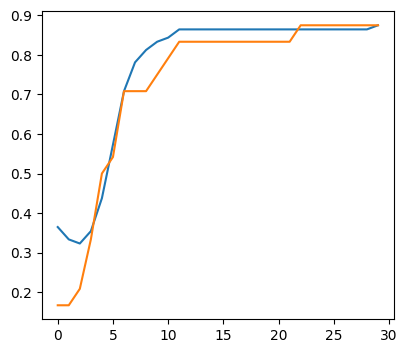

In [12]:
 import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training')
plt.plot(history.history['val_accuracy'], label='Validation')

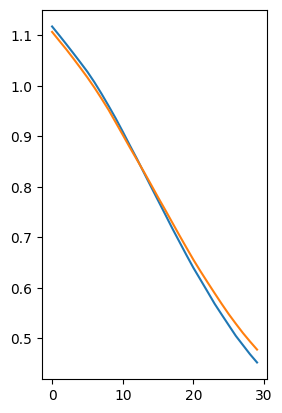

In [13]:
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training')
plt.plot(history.history['val_loss'], label='Validation')

Shows how training and validation accuracy and loss change across epochs.

**Why Softmax?**

Iris has three possible classes, so Softmax produces a probability for each class that adds up to 1. A single Sigmoid neuron is mainly used for binary classification.